In [ ]:
!pip install transformers datasets accelerate evaluate scikit-learn pandas numpy torch

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import numpy as np
import torch

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [ ]:
from datasets import load_dataset

In [ ]:
from datasets import load_dataset

dataset = load_dataset("dair-ai/emotion")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
dataset["train"][0]

{'text': 'i didnt feel humiliated', 'label': 0}

In [ ]:
dataset["train"].features["label"]

ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'], id=None)

In [ ]:
len(dataset["train"])

16000

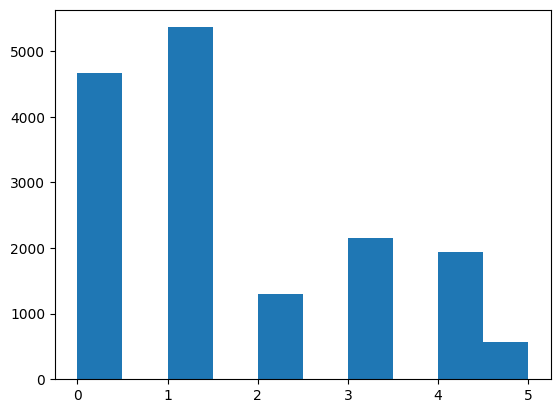

In [ ]:
labels = dataset["train"]["label"]

plt.hist(labels)

plt.show()

In [ ]:
model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=6
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def tokenize(batch):

    return tokenizer(

        batch["text"],

        truncation=True,

        padding="max_length",

        max_length=128

    )

In [ ]:
tokenized_dataset = dataset.map(tokenize, batched=True)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
tokenized_dataset.set_format(

    "torch",

    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

In [ ]:
def compute_metrics(pred):

    labels = pred.label_ids

    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(

        labels,

        preds,

        average="weighted"

    )

    acc = accuracy_score(labels, preds)

    return {

        "accuracy": acc,

        "precision": precision,

        "recall": recall,

        "f1": f1,

    }

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none"
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.228800,0.197926,0.923500,0.926167,0.923500,0.923949
2,0.137700,0.160630,0.939000,0.940114,0.939000,0.938432
3,0.077300,0.171919,0.940000,0.940408,0.940000,0.939895


TrainOutput(global_step=3000, training_loss=0.2416194543838501, metrics={'train_runtime': 1235.2156, 'train_samples_per_second': 38.86, 'train_steps_per_second': 2.429, 'total_flos': 3157446057984000.0, 'train_loss': 0.2416194543838501, 'epoch': 3.0})

In [ ]:
trainer.evaluate(tokenized_dataset["test"])

{'eval_loss': 0.1817488968372345,
 'eval_accuracy': 0.929,
 'eval_precision': 0.9287452395105285,
 'eval_recall': 0.929,
 'eval_f1': 0.9285586459985544,
 'eval_runtime': 16.0129,
 'eval_samples_per_second': 124.899,
 'eval_steps_per_second': 7.806,
 'epoch': 3.0}

In [ ]:
model.save_pretrained("bert_emotion_model")

tokenizer.save_pretrained("bert_emotion_model")

('bert_emotion_model/tokenizer_config.json',
 'bert_emotion_model/special_tokens_map.json',
 'bert_emotion_model/vocab.txt',
 'bert_emotion_model/added_tokens.json',
 'bert_emotion_model/tokenizer.json')

In [ ]:
from google.colab import files
import shutil

shutil.make_archive("bert_emotion_model", "zip", "bert_emotion_model")

files.download("bert_emotion_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch

text = "I am feeling stressed because of exams."

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to the device
model.to(device)

# Tokenize
inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True
)

# Move inputs to the same device
inputs = {k: v.to(device) for k, v in inputs.items()}

# Prediction
model.eval()

with torch.no_grad():
    outputs = model(**inputs)

prediction = torch.argmax(outputs.logits, dim=1)

labels = [
    "sadness",
    "joy",
    "love",
    "anger",
    "fear",
    "surprise"
]

print("Predicted Emotion:", labels[prediction.item()])

Predicted Emotion: sadness


In [ ]:
import torch

# Put model on GPU (if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

labels = [
    "sadness",
    "joy",
    "love",
    "anger",
    "fear",
    "surprise"
]

examples = [
    "I am very happy today.",
    "I feel depressed.",
    "I am scared of tomorrow.",
    "Everything is amazing.",
    "I don't feel like talking to anyone."
]

for sentence in examples:

    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    # Move inputs to GPU
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    pred = torch.argmax(outputs.logits, dim=1)

    print("Sentence:", sentence)
    print("Prediction:", labels[pred.item()])
    print("-" * 40)

Sentence: I am very happy today.
Prediction: joy
----------------------------------------
Sentence: I feel depressed.
Prediction: sadness
----------------------------------------
Sentence: I am scared of tomorrow.
Prediction: fear
----------------------------------------
Sentence: Everything is amazing.
Prediction: joy
----------------------------------------
Sentence: I don't feel like talking to anyone.
Prediction: joy
----------------------------------------
